In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time

import geopandas as gpd

from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

ERROR 1: PROJ: proj_create_from_database: Open of /home/lhasbini/.conda/envs/dev/share/proj failed


In [3]:
all_reports = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')

## Map nb of events + types of events 

In [4]:
all_reports_grp = all_reports.groupby('appealCode').agg(country = ("country", "first")).reset_index()

In [37]:
hazard_counts.index

Index(['Africa', 'Asia', 'Europe', 'North America', 'Oceania',
       'South America'],
      dtype='object', name='continent')

/tmp/ipykernel_4010178/3626837251.py:21: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


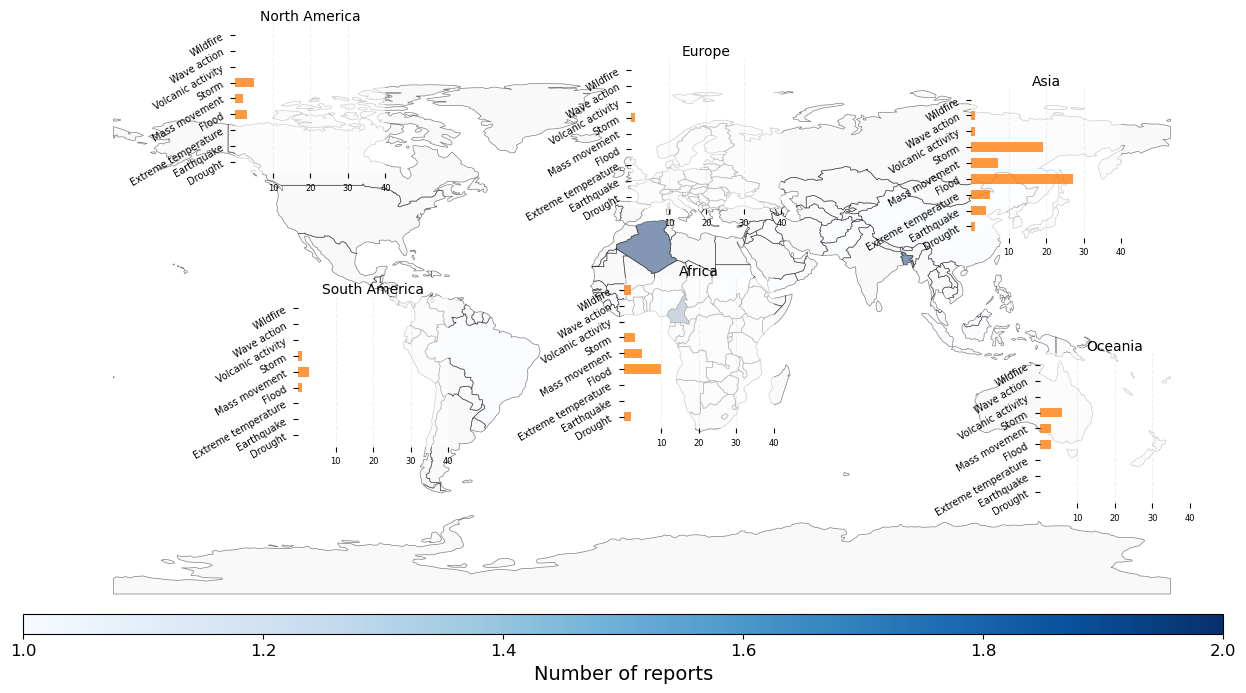

In [133]:
import pycountry
import geopandas as gpd
from collections import defaultdict

# Step 1: Map country names to ISO codes and count unique appeal codes per country
country_appeal_count = defaultdict(set)

for appeal_code, country_name in zip(all_reports_grp['appealCode'], all_reports_grp['country']):
    try:
        country = pycountry.countries.get(name=country_name)
        if country:
            iso_code = country.alpha_3  # ISO 3166-1 Alpha-3 code
            country_appeal_count[iso_code].add(appeal_code)  # Add unique appealCode
    except KeyError:
        continue
country_appeal_count = {iso: len(codes) for iso, codes in country_appeal_count.items()}

# Step 2: Create a DataFrame from the counts
df = pd.DataFrame(list(country_appeal_count.items()), columns=["iso_code", "appeal_count"])

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world.merge(df, how="left", left_on="iso_a3", right_on="iso_code")

# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries

# Plot the map with color based on the appeal_count column
world_plot = world.plot(column="appeal_count", 
                        ax=ax, 
                        legend=False, 
                        cmap="Blues", 
                        missing_kwds={
                            "color": "whitesmoke",
                            "label": "No data"
                        }, alpha=0.5)

# Reduce the size of the colorbar
sm = plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(vmin=world['appeal_count'].min(), vmax=world['appeal_count'].max()))
sm._A = []  # Dummy array for ScalarMappable
cbar_ax = fig.add_axes([0.1, 0.2, 0.8, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Number of reports", fontsize=14)

# Set plot title and labels
# ax.set_title("Appeal frequency per country", fontsize=16)
ax.set_axis_off()  # Hide axis


# --- Step 4: Group hazard types by continent and plot histogram ---
# Get continent for each country
def get_continent(iso_code):
    try:
        return world[world['iso_a3'] == iso_code]['continent'].values[0]
    except IndexError:
        return None

# Map ISO codes to continents
all_reports['continent'] = all_reports['country'].apply(
    lambda x: get_continent(pycountry.countries.get(name=x).alpha_3) if pycountry.countries.get(name=x) else None
)

# Filter out rows without continent
valid_continents = all_reports.dropna(subset=['continent'])

# Group by continent and hazard type
hazard_counts = valid_continents.groupby(['continent', 'hazardType']).size().unstack(fill_value=0)

# --- Step 5: Plot mini horizontal bars on continents ---
# Get centroids of dissolved continents
continent_offsets = {
    'Africa': (0, -0.1),
    'Asia': (0.05, -0.05),
    'Europe': (-0.15, -0.17),
    'Oceania' : (-0.05, 0), 
    'North America' : (0.05, -0.1), 
    'South America' : (0, 0)
}

continent_shapes = world.dissolve(by='continent')#.to_crs('ESRI:54030')
# continent_centroids = continent_shapes.geometry.centroid
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid

# Reproject centroids back to original CRS (WGS84) to overlay on the map
continent_centroids = continent_centroids_proj.to_crs(world.crs)

# Plot only for continents with data
for continent in hazard_counts.index:
    if continent not in continent_centroids.index:
        continue
        
    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue
    
    try:
        # Create a small axis for the bar plot
        norm_x = (centroid.x + 180) / 360
        norm_y = (centroid.y + 90) / 180 
        x_offset, y_offset = continent_offsets.get(continent, (0, 0))
        
        ax_bar = fig.add_axes([norm_x - 0.05 + x_offset, norm_y - 0.03 + y_offset, 0.1, 0.15]) 

        data = hazard_counts.loc[continent]
        # print("Before plot")
        # if not data.empty:
        # Filter out zero values for cleaner visualization
        ax_bar.set_facecolor('white')
        ax_bar.patch.set_alpha(0.6)
        
        values = data.values
        labels = data.index.str.wrap(10)
        
        ax_bar.barh(
            y=range(len(values)), 
            width=values, 
            color='tab:orange', 
            alpha=0.8, 
            height=0.6
        )
        
        ax_bar.set_title(continent[:15], fontsize=10, pad=2)
        ax_bar.title.set_position([0.5, 1.1])
        
        ax_bar.set_xticks(np.arange(10, 50, 10))  # 5 tick marks evenly spaced
        ax_bar.tick_params(axis='x', labelsize=6)
        
        ax_bar.set_yticks(range(len(labels)))  # Consistent y-ticks for all plots
        ax_bar.set_yticklabels(data.index, fontsize=7, rotation=30)
        for spine in ax_bar.spines.values():
            spine.set_visible(False)
        ax_bar.grid(axis='x', alpha=0.2, linestyle='--')      
    except Exception as e:
        print(f"Error plotting {continent}: {e}")
        continue  # Skip if there's any error creating the mini plot
# plt.tight_layout()

plt.show()